Found 5494 files belonging to 12 classes.
Using 4396 files for training.
Found 5494 files belonging to 12 classes.
Using 1098 files for validation.
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
Epoch 1/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 231s 2s/step - accuracy: 0.6931 - loss: 1.0491 - val_accuracy: 0.9053 - val_loss: 0.3169
Epoch 2/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 239s 2s/step - accuracy: 0.8857 - loss: 0.3770 - val_accuracy: 0.9162 - val_loss: 0.2869
Epoch 3/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.9156 - loss: 0.2840 - val_accuracy: 0.9235 - val_loss: 0.2817
Epoch 4/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - accuracy: 0.9224 - loss: 0.2410 - val_accuracy: 0.9144 - val_loss: 0.2863
Epoch 5/5
138/138 ━━━━━━━━━━━━━━━━━━━━ 267s 2s/step - accuracy: 0.9398 - loss: 0.1999 - val_accuracy: 0.9226 - val_loss: 0.2786


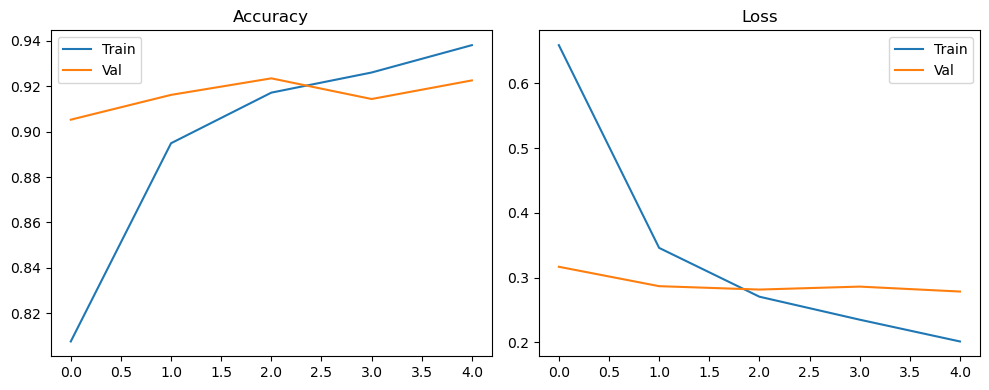

In [2]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Config
dataset_dir = r"D:\Ed\DL\Proj\pest" # CHANGE THIS
img_size = (299, 299)  # Xception input size
batch_size = 32
epochs = 5

# Load data
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)

# Prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# Preprocess
preprocess_input = tf.keras.applications.xception.preprocess_input

# Model
base_model = Xception(include_top=False, weights='imagenet', input_shape=img_size + (3,))
base_model.trainable = False

inputs = layers.Input(shape=img_size + (3,))
x = preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

model.save("xception_pest_classifier.h5")

# Plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("xception_training_plot.png")
plt.show()
